# 🤖 Building a Generative Pretrained Transformer (GPT)

## ⚽ Goal of this Lab

> **Building on [Lab 2](https://github.com/athnlp/athnlp-labs-2026-teachers/blob/main/labs/athnlp_lab_2_2026.ipynb).** In Lab 2 we built an RNN language model with this pipeline:
> `raw text → tokens → embed → RNN → project → train → generate`.
> Now we **replace the RNN with a Transformer**. The data pipeline, training loop, and inference stay the same — only the core sequence modelling block changes.

Transformers, introduced in the 2017 paper [*Attention is All You Need*](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf) are the foundational neural network architecture for most state-of-the-art Natural Language Processing (NLP) models, including Large Language Models (LLMs) like ChatGPT, Gemini, and LLaMA. These models learn to predict the next token in a sequence by modeling relationships between tokens. While initially applied to machine translation, the Transformer architecture has rapidly expanded its influence across AI fields such as [*computer vision*](https://proceedings.mlr.press/v139/radford21a), [*audio processing*](https://scontent.fath4-2.fna.fbcdn.net/v/t39.2365-6/406941874_247486308347770_2317832131512763077_n.pdf?_nc_cat=102&ccb=1-7&_nc_sid=3c67a6&_nc_ohc=hzLHysYvyscQ7kNvgG632q4&_nc_ht=scontent.fath4-2.fna&_nc_gid=Acqsypm_wc2ArPN_j-I53Yw&oh=00_AYCfXJA0aKFkpaA4IGyCThixjpWHwg6nnElq7n35HhnUjA&oe=66EED669), and [*video processing*](https://proceedings.mlr.press/v139/bertasius21a/bertasius21a.pdf), often with minimal modifications.


<div align="center">

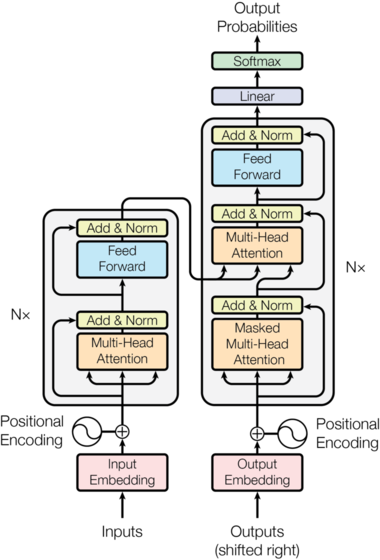

The original Transformer model shown above, follows an encoder-decoder architecture.

Here, the encoder (left) maps an input sequence of symbols (tokens) $\mathbf{x} = (x_1, x_2, \dots, x_n)$, to a sequence of continuous representations $\mathbf{z} = (z_1, z_2, \dots, z_n)$. $\mathbf{z}$ is a latent representation of our input sequence that is given to the decoder (right) in order to complete it.

In other words, given $\mathbf{z}$, the decoder generates an output sequence of symbols $\mathbf{y} = (y_1, y_2, \dots y_m)$, one symbol at a time. Each time the model produces an output $y_i$, this symbol is appended at the input in order to generate the next symbol $y_{i+1}$. These models that use their previously generated input to produce the next one are called auto-regressive.

For example, the encoder might take an English sentence as input and produce latent representations, which the decoder then uses to generate the French translation. In a decoder-only model, there is no separate encoder. The same module takes past tokens (e.g., words already generated) and predicts the next one, making it suitable for tasks like text completion and language modeling.

> We will be focusing on a **Decoder**-only architecture.

## 🧐 What’s the Plan?

In this project, we will draw from the original paper and [Andrej Karpathy's `nanoGPT`](https://github.com/karpathy/nanoGPT) to develop and train a  Generatively Pretrained Transformer (GPT). Our goal is to understand transformers as neural networks that learn to model word sequences effectively.

> **IMPORTANT:** We won’t build full-scale systems like ChatGPT or Gemini. These are production-grade models trained on vast datasets with complex multi-stage pipelines far beyond the scope of this lab.

## 📦 Installing the Necessary Dependencies

- [`PyTorch`](https://pytorch.org/) – A powerful library for building and training neural networks, providing Tensors for deep learning workflows.
- [`Transformers`](https://huggingface.co/docs/transformers/index) – Provides APIs and tools to easily download and train state-of-the-art pretrained models, including the `Trainer` API.
- [`Datasets`](https://huggingface.co/docs/datasets/index) – A library for easily accessing and sharing datasets for Audio, Computer Vision, and NLP tasks.
- [`Accelerate`](https://huggingface.co/docs/accelerate/index) – Enables the same PyTorch code to be run across any distributed configuration (Multi-GPU, TPU, etc.).
- [`Altair`](https://altair-viz.github.io/) – A declarative statistical visualization library for Python for creating clear charts.
- [`Matplotlib`](https://matplotlib.org/) – A comprehensive library for creating static, animated, and interactive visualizations in Python.
- [`Pandas`](https://pandas.pydata.org/) – A fast, flexible data analysis library providing DataFrames for structured data manipulation.
- [`tqdm`](https://tqdm.github.io/) – A progress bar library that provides visual feedback during loops and training.

In [1]:
# @title Install Dependencies

# -----------------------------------------------------------------------------
# Install libraries
# -----------------------------------------------------------------------------
!pip install -q --upgrade \
    pandas \
    transformers \
    accelerate \
    datasets \
    altair \
    tqdm \
    matplotlib \
    tokenizers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.6/797.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pan

## 🗺️ Exploring the dataset

As in Lab 2 Part 1a, we start with raw text. Here we use the same Tiny Shakespeare dataset with a character-level vocabulary (the simplest tokenisation).


In [2]:
import math
from typing import Any

import altair as alt
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from datasets import Dataset
from tokenizers import Tokenizer, models, normalizers, pre_tokenizers, trainers
from tokenizers.processors import TemplateProcessing
from torch.nn import functional as F
from transformers import PreTrainedTokenizerFast, Trainer, TrainingArguments

In [3]:
# @title Downloading the dataset (same as Lab 2)

!wget -q --show-progress https://raw.githubusercontent.com/karpathy/ng-video-lecture/refs/heads/master/input.txt -O input.txt

with open("input.txt") as f:
    text = f.read()

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.06s   


In [4]:
# @title Train a word-level tokenizer (same as Lab 2)

def train_word_level_tokenizer(
    *,
    sentences: list[str],
    unk_token: str = "[UNK]",  # noqa: S107
    pad_token: str = "[PAD]",  # noqa: S107
    start_of_seq_token: str = "<s>",  # noqa: S107
    end_of_seq_token: str = "</s>",  # noqa: S107
) -> PreTrainedTokenizerFast:
    special_tokens = [unk_token, pad_token, start_of_seq_token, end_of_seq_token]
    trainer = trainers.WordLevelTrainer(
        special_tokens=special_tokens, show_progress=True
    )
    tokenizer = Tokenizer(models.WordLevel(unk_token=unk_token))
    tokenizer.normalizer = normalizers.Sequence(
        [normalizers.NFD(), normalizers.Strip()]
    )
    tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
    tokenizer.post_processor = TemplateProcessing(
        single=f"{start_of_seq_token} $A {end_of_seq_token}",
        special_tokens=[
            (start_of_seq_token, special_tokens.index(start_of_seq_token)),
            (end_of_seq_token, special_tokens.index(end_of_seq_token)),
        ],
    )
    tokenizer.train_from_iterator(sentences, trainer=trainer)
    tokenizer.enable_padding(
        pad_id=special_tokens.index(pad_token), pad_token=pad_token
    )
    pretrained_tokenizer = PreTrainedTokenizerFast(
        bos_token=start_of_seq_token,
        eos_token=end_of_seq_token,
        unk_token=unk_token,
        pad_token=pad_token,
        clean_up_tokenization_spaces=True,
        tokenizer_object=tokenizer,
    )
    return pretrained_tokenizer


tokenizer = train_word_level_tokenizer(sentences=[text])
print(f"Vocabulary size: {tokenizer.vocab_size}")

all_ids = torch.tensor(tokenizer.encode(text), dtype=torch.long)
print(f"Total tokens: {len(all_ids)}")

# Create tokenized_dataset for the HF Trainer by splitting into fixed-length chunks
chunk_size = 128
n_chunks = len(all_ids) // chunk_size
tokenized_dataset = Dataset.from_dict({
    "input_ids": [all_ids[i * chunk_size : (i + 1) * chunk_size].tolist() for i in range(n_chunks)]
})
print(f"Training examples: {len(tokenized_dataset)}")

Vocabulary size: 13359
Total tokens: 261975
Training examples: 2046


## 🚀 Attention is **(almost)** all you need!

Imagine trying to read a very long book, and your task is to predict the very next word at any point. If you treated every single word you've read so far with the same importance—whether it was the first word of the book or the one just before the current one—you'd quickly get confused. The sheer volume of equally weighted information would lead to **gibberish**.

This is precisely the problem traditional neural networks faced when dealing with long sequences of information, like sentences or paragraphs. They struggled to understand which parts of the input were most relevant at a given moment, leading to poor predictions. Without attention — as you saw in Lab 2 with the RNN — the model struggles with longer contexts because it compresses everything into a single hidden state. For a Transformer, we need a mechanism that lets each token directly attend to all other tokens in the sequence.

**What is Attention?**

Think about how *you* focus. If someone asks you to find a red car in a busy street photo, your eyes don't randomly scan every single pixel. Instead, you **focus** on specific areas that are red and shaped like a car.

In the world of neural networks, **attention** is a clever mechanism that lets the model mimic this human ability to **focus**. It solves the compression problem by allowing the network to dynamically **weigh the importance of different parts of its input** when making a decision. Instead of relying on a single, fixed summary, the network gains the ability to "look back" at all the original input data and decide, in real-time, which pieces are most relevant for the specific task at hand.

<div align="center">

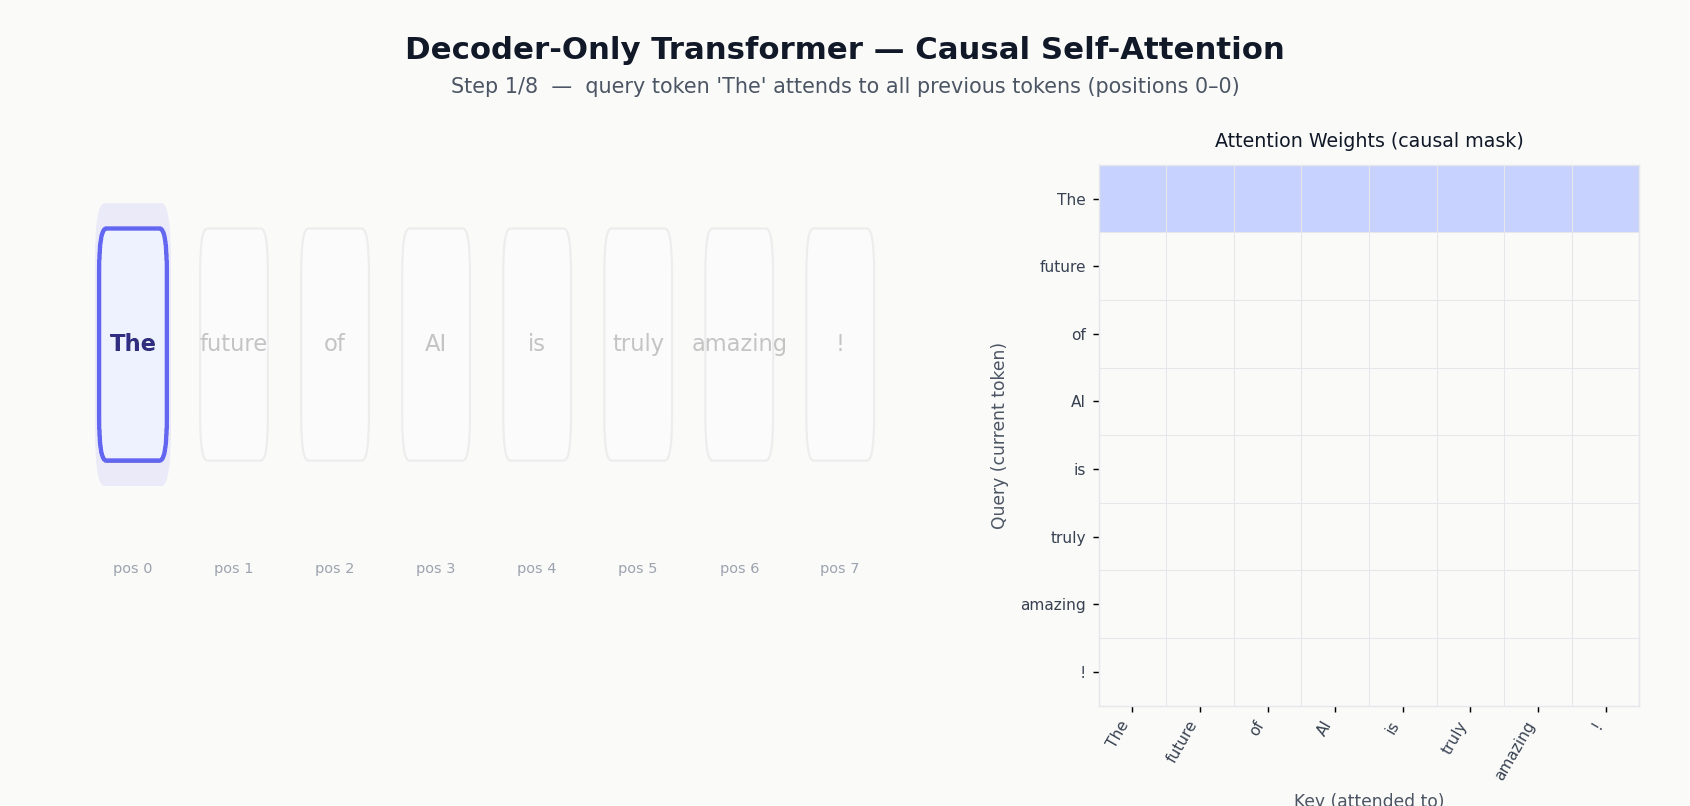

<div>

### 🔢 And now math!

On a high-level attention is a mechanism that allows each token in a sequence to *see* any other token. So in the toy example above, we have 4 words that we want to connect to each other. Recall that in language modeling, given a prefix string, we are trying to predict the next token that is a suitable continuation for that prefix string.


By default, the attention mechanism will allow you to *connect* one token with every other token. However, in sequence modeling tasks, the token at position 2 ("sat") should only communicate with the tokens at position 0 and 1 ("the" and "cat"), because the token at position 3 ("on") is a future token. In other words, the token at timestep $\tau$ should not communicate to any token in the future $\tau+{n}$.




**Information only flows from previous tokens to the current timestep, we do not get any information from the future tokens because we are trying to predict them.**

In [5]:
# We start with a simple sequence of 4 words, each represented by a 2-dimensional embedding.
# These embeddings are hand-crafted so we can trace through the math concretely.
words = ["AI", "is", "really", "awesome"]
sequence_length = len(words)
embedding_size = 2
embeddings = torch.tensor([
    [1.0, 0.5],  # AI
    [0.2, 1.0],  # is
    [0.8, 0.3],  # really
    [0.4, 0.7],  # awesome
])
print(f"Sequence: {words}")
print(f"Embeddings shape: {embeddings.shape}")
print(embeddings)

Sequence: ['AI', 'is', 'really', 'awesome']
Embeddings shape: torch.Size([4, 2])
tensor([[1.0000, 0.5000],
        [0.2000, 1.0000],
        [0.8000, 0.3000],
        [0.4000, 0.7000]])


**Question** What is the easiest way for tokens to communicate with each other?

<details>
<summary><strong>Answer</strong></summary>

The simplest approach is to calculate a running average. In other words, each running average is a <strong>uniform-weighted sum</strong> of all past embeddings.

To build context for the 5th token, you simply average its embedding with the four tokens that came before it. This creates a single feature vector that summarizes the present moment alongside its entire history.

However, simple averaging is an extremely lossy compression. Because addition is commutative ($x_1 + x_2 + x_3 = x_3 + x_2 + x_1$), this method completely destroys sequence order. In language modeling, word order dictates meaning—but to build our baseline, this running average is a great starting point!
</details>

In [6]:
running_average = torch.zeros((sequence_length, embedding_size))
for t in range(sequence_length):
    # The previous chunk of tokens at timestep t are the tokens all the way until t+1
    previous_tokens = embeddings[:t+1]
    # Average all the previous tokens over the zero dimension (aka time)
    running_average[t] = torch.mean(previous_tokens, 0)

for t in range(sequence_length):
    weight = 1.0 / (t + 1)

    # 1. The symbolic terms (e.g., 0.5*emb[0] + 0.5*emb[1])
    terms_sym = " + ".join([f"{weight:.4g} * emb[{j}]" for j in range(t + 1)])

    # 2. The numeric terms (e.g., 0.5*[1.0, 0.5] + 0.5*[0.2, 1.0])
    terms_num = " + ".join(
        [
            f"{weight:.4g} * {[round(val, 4) for val in embeddings[j].tolist()]}"
            for j in range(t + 1)
        ]
    )

    # 3. The final computed vector
    result_vals = [round(val, 4) for val in running_average[t].tolist()]

    # Changed >7s to ^7s for center alignment
    print(f"  avg[{t}] ({words[t]:^7s}) = {terms_sym}")
    print(f"                   = {terms_num}")
    print(f"                   = {result_vals}\n")

  avg[0] (  AI   ) = 1 * emb[0]
                   = 1 * [1.0, 0.5]
                   = [1.0, 0.5]

  avg[1] (  is   ) = 0.5 * emb[0] + 0.5 * emb[1]
                   = 0.5 * [1.0, 0.5] + 0.5 * [0.2, 1.0]
                   = [0.6, 0.75]

  avg[2] (really ) = 0.3333 * emb[0] + 0.3333 * emb[1] + 0.3333 * emb[2]
                   = 0.3333 * [1.0, 0.5] + 0.3333 * [0.2, 1.0] + 0.3333 * [0.8, 0.3]
                   = [0.6667, 0.6]

  avg[3] (awesome) = 0.25 * emb[0] + 0.25 * emb[1] + 0.25 * emb[2] + 0.25 * emb[3]
                   = 0.25 * [1.0, 0.5] + 0.25 * [0.2, 1.0] + 0.25 * [0.8, 0.3] + 0.25 * [0.4, 0.7]
                   = [0.6, 0.625]



The weight matrix that produces the running average is a uniform triangular matrix. Each row tells us how much each token attends to its predecessors. This is an "attention pattern" — uniform over past tokens.

By simply multiplying this weight matrix by our original embeddings, we calculate the running average for the entire sequence all at once.

In [7]:
uniform_weights = torch.tril(torch.ones(sequence_length, sequence_length))
uniform_weights = uniform_weights / uniform_weights.sum(1, keepdim=True)

# The Output (Weights x Embeddings) -> This is your running average!
running_average = uniform_weights @ embeddings

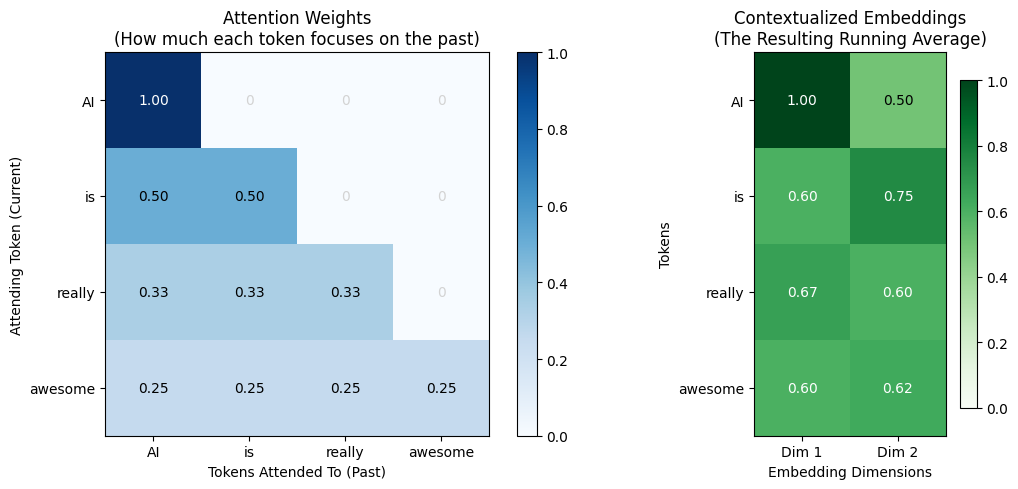

In [8]:
# @title Visualizing the uniform weights and the running average

# We use gridspec to make the left plot wider than the right plot (4x4 vs 4x2)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [2, 1]})

# --- Left Plot: Attention Weights ---
im0 = axes[0].imshow(uniform_weights.numpy(), cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("Attention Weights\n(How much each token focuses on the past)")
axes[0].set_xlabel("Tokens Attended To (Past)")
axes[0].set_ylabel("Attending Token (Current)")
axes[0].set_xticks(range(sequence_length))
axes[0].set_xticklabels(words)
axes[0].set_yticks(range(sequence_length))
axes[0].set_yticklabels(words)

# Add text to left plot, making zeros faint so the triangle shape pops
for i in range(sequence_length):
    for j in range(sequence_length):
        val = uniform_weights[i, j].item()
        if val > 0:
            color = "white" if val > 0.6 else "black"
            axes[0].text(j, i, f"{val:.2f}", ha="center", va="center", color=color)
        else:
            axes[0].text(j, i, "0", ha="center", va="center", color="lightgray")

plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- Right Plot: The Output (Weights x V) ---
im1 = axes[1].imshow(running_average.numpy(), cmap="Greens", vmin=0, vmax=1)
axes[1].set_title("Contextualized Embeddings\n(The Resulting Running Average)")
axes[1].set_xlabel("Embedding Dimensions")
axes[1].set_ylabel("Tokens")
axes[1].set_xticks(range(embedding_size))
axes[1].set_xticklabels(["Dim 1", "Dim 2"])
axes[1].set_yticks(range(sequence_length))
axes[1].set_yticklabels(words)

# Add text to right plot
for i in range(sequence_length):
    for j in range(embedding_size):
        val = running_average[i, j].item()
        color = "white" if val > 0.6 else "black"
        axes[1].text(j, i, f"{val:.2f}", ha="center", va="center", color=color)

plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### 🧠 From uniform to learned attention weights

In our running average, the attention weights were static — masked, normalized, and strictly uniform, treating every past token as equally important.

In a real Transformer, these weights are **learned directly from the data**. To make attention dynamic and context-aware, each token (like the word "cat") projects two distinct vectors:

* **A Query** *(what am I looking for?)* — e.g., *"I'm 'cat' — are there any adjectives describing me?"*
* **A Key** *(what do I contain?)* — e.g., *"I'm 'cat' — a singular animal noun."*

To turn raw embeddings into Queries and Keys, we use **projection weight matrices** ($W_Q$ and $W_K$).

Think of a projection matrix as a **filter**:

1. **The Projection Matrix ($W_Q$)** acts as a recipe that tells the model: *"Take the raw features of an embedding and reshape them into a Query request."*
2. **The Operation ($Q = \text{embeddings} \times W_Q$):** You multiply your stack of word embeddings by this projection matrix.
3. **The Result ($Q$):** A new matrix where **each row** is now the specific **Query vector** for that token.

> The same exact process applies using $W_K$ to produce the **Key matrix** $K$.

$$\begin{aligned} Q &= \text{embeddings} \times W_Q \quad \text{(Stack of Query vectors)} \\ K &= \text{embeddings} \times W_K \quad \text{(Stack of Key vectors)} \end{aligned}$$

In [9]:
w_q = torch.tensor([[0.0, 4.0], [3.0, 0.0]])
w_k = torch.tensor([[9.0, 0.0], [0.0, 2.0]])

# Project embeddings into query and key spaces
Q = embeddings @ w_q
K = embeddings @ w_k

The raw, unnormalized attention score between two tokens is the dot product of one's query with the other's key. We use the dot product because it naturally measures mathematical similarity — if a query and a key match well, their vectors align, resulting in a higher score.

By multiplying $Q \times K^T$, we compute the dot product between **every query vector and every key vector** all at once, giving us our raw attention scores.

In [10]:
raw_scores = Q @ K.T
print("\nRaw Attention Scores (Q @ K.T):")
print(raw_scores)


Raw Attention Scores (Q @ K.T):
tensor([[17.5000, 10.7000, 13.2000, 11.0000],
        [27.8000,  7.0000, 22.0800, 11.9200],
        [11.3000,  8.0200,  8.4000,  7.7200],
        [20.5000,  6.9800, 16.0800,  9.8000]])


However, raw dot products can output any arbitrary number (large, small, positive, or negative). To turn these raw scores into proper attention weights (fractions), we need to normalize them — **Softmax comes to the rescue!**

The Softmax function converts raw scores (logits) into a probability distribution: non-negative values that sum to $1$ for each token $i$ across all $J$ tokens:

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{J} e^{z_j}}$$

Additionally, if we compute dot products between all tokens, a word could "cheat" by attending to future words. To prevent this and mimic our causal running average, we apply a mask right before the softmax step by setting the raw attention scores of all future tokens to negative infinity ($-\infty$).

Because the softmax function uses exponentials, any masked position with $z_i = -\infty$ becomes $e^{-\infty} = 0$. Softmax seamlessly solves both problems at once: normalizing raw scores into weights while elegantly guaranteeing that future tokens get exactly 0% of the attention.

In [11]:
mask = torch.triu(torch.ones(sequence_length, sequence_length), diagonal=1).bool()

masked_scores = raw_scores.masked_fill(mask, float("-inf"))
print("Masked Scores (Future tokens set to -inf):")
print(masked_scores.round(decimals=2))

attention_weights = F.softmax(masked_scores, dim=-1)
print("Attention Weights (Softmax of Masked Scores):")
print(attention_weights.round(decimals=2))

Masked Scores (Future tokens set to -inf):
tensor([[17.5000,    -inf,    -inf,    -inf],
        [27.8000,  7.0000,    -inf,    -inf],
        [11.3000,  8.0200,  8.4000,    -inf],
        [20.5000,  6.9800, 16.0800,  9.8000]])
Attention Weights (Softmax of Masked Scores):
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [1.0000, 0.0000, 0.0000, 0.0000],
        [0.9200, 0.0300, 0.0500, 0.0000],
        [0.9900, 0.0000, 0.0100, 0.0000]])


Finally, what about the actual content we want to extract? That's where the **Value Matrix ($V$)** comes in.

Just like Queries and Keys, we pass our embeddings through a learned projection weight matrix ($W_V$) to produce $V$, where each row is a token's **Value vector**:

* **A Value** *(what information do I provide?)* — e.g., *"Here is the core semantic meaning of 'AI' to blend into the context."*

> While our running average directly averaged raw input embeddings, self-attention transforms them into a **Value Matrix** first—allowing the model to separate *how a token advertises itself* (Key) from *the actual information it contributes* (Value).

The final output for the sequence is computed by multiplying the normalized Softmax attention weights by the **Value Matrix ($V$)**, giving each token a customized, weighted blend of context.

In [12]:
# Value projection matrix (using Identity matrix for simplicity: keep features as is)
w_v = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
V = embeddings @ w_v

final_output = attention_weights @ V
print("\nFinal Output Contextual Embeddings:")
print(final_output.round(decimals=2))


Final Output Contextual Embeddings:
tensor([[1.0000, 0.5000],
        [1.0000, 0.5000],
        [0.9600, 0.5100],
        [1.0000, 0.5000]])


Pause for a moment to ponder what we have built. **The core blueprint is identical to our initial running average—we simply made every hardcoded piece trainable.**

```
  Running Average                      Causal Self-Attention
  ---------------                      ---------------------
[ Static Weights ]                    [ Learned Query/Key ]
        │                                       │
        ▼                                       ▼
[ Fixed Masking ] ──────► SAME ──────► [ Softmax + Masking ]
        │               BLUEPRINT               │
        ▼                                       ▼
[ Raw Embeddings ]                    [ Value Vectors (V) ]

```

At its core, **attention is a mechanism for computing a weighted average of information across a sequence.** Each token aggregates representations from others, with the weights determining how much influence each token has:

* **Dynamic Weights over Static Averages:** In our running average, all allowed token interactions had the same fixed score, producing uniform weights ($\frac{1}{t+1}$). In a real Transformer, interaction strengths are dynamically computed from the data—tokens effectively "look" at one another ($Q \times K^T$), assigning higher or lower importance based on relevance.
* **Identical Causal Masking:** Both approaches impose a triangular (causal) mask to prevent tokens from attending to future positions, ensuring predictions rely solely on previously available information.
* **Normalized Payload Aggregation:** Instead of averaging raw input embeddings, the attention scores are normalized via Softmax into weights that sum to 1, which are then used to compute a weighted sum of transformed **Value vectors ($V$)**.

### ❔ Let's revisit the Running Average

We started with a simple running average and evolved it into dynamic self-attention. Now, let's come full circle: we can force our attention mechanism to perfectly mimic that original running average just by tweaking the projection matrices.

* **$W_Q$ and $W_K$ as Zeros ("Nobody is special"):** Setting these to zero means every token asks for nothing ($Q=0$) and advertises nothing ($K=0$). With no token standing out, all attention scores tie at $0$. Softmax splits the tie equally across all valid past tokens, recreating our uniform fractions.
* **$W_V$ as Identity ("Be yourself"):** An Identity matrix acts like a mirror. It bypasses any feature extraction, forcing the tokens to contribute their raw, original embeddings to the final blend.

By stripping away the network's ability to play favorites ($Q, K=0$) and transform data ($V=\text{Identity}$), we turn a smart routing system back into a basic running average. Let's prove it in code!

In [ ]:
# 1. Zero out Q and K projections, keep V as Identity
w_q_uniform = torch.zeros((embedding_size, embedding_size))
w_k_uniform = torch.zeros((embedding_size, embedding_size))
w_v_uniform = torch.eye(embedding_size)

# 2. Project
Q_uniform = embeddings @ w_q_uniform
K_uniform = embeddings @ w_k_uniform
V_uniform = embeddings @ w_v_uniform

# 3. Calculate Scores, Mask, and Softmax
raw_scores_uniform = Q_uniform @ K_uniform.T
# (Reusing the mask from the previous cells)
masked_scores_uniform = raw_scores_uniform.masked_fill(mask, float("-inf"))
attention_weights_uniform = F.softmax(masked_scores_uniform, dim=-1)

# 4. Final Output
attention_running_average = attention_weights_uniform @ V_uniform

print("Uniform Attention Weights:\n", attention_weights_uniform.round(decimals=4))
print("\nAttention Output:\n", attention_running_average.round(decimals=4))


### 📦 Batching it up

So far, we have worked with a single sequence of 4 tokens. During training and inference, however, we rarely process one sequence at a time. Instead, we group multiple independent sequences together into a batch and process them simultaneously.

For example, instead of a single sequence:

$$
[x_1, x_2, x_3, x_4]
$$

we might process a batch of several sequences:

$$
\begin{bmatrix}
x_1^{(1)} & x_2^{(1)} & x_3^{(1)} & x_4^{(1)} \\
x_1^{(2)} & x_2^{(2)} & x_3^{(2)} & x_4^{(2)} \\
x_1^{(3)} & x_2^{(3)} & x_3^{(3)} & x_4^{(3)}
\end{bmatrix}
$$

where each row represents a separate sequence. The attention operation is applied independently to each sequence, but the matrix operations are performed together for efficiency.
Mathematically, nothing fundamental changes—we simply add an extra batch dimension to our tensors. Instead of operating on a matrix of shape:

$$
(\text{sequence length}, \text{embedding dimension})
$$

we now operate on a tensor of shape:

$$
(\text{batch size}, \text{sequence length}, \text{embedding dimension})
$$

The attention equations remain the same; the additional dimension tells PyTorch to perform the exact same operations for every sequence in the batch independently, allowing modern GPUs to process many examples in parallel.

In [ ]:
torch.manual_seed(1337)

# 1. Setup dimensions and batch data
batch_size = 4
sequence_length = 8
embedding_size = 2  # d_model

# Batch shape: (batch_size, sequence_length, embedding_size) -> (4, 8, 2)
batch = torch.randn(batch_size, sequence_length, embedding_size)
print(f"Input batch shape: {batch.shape}")

# 2. Define projection weights (W_Q, W_K, W_V)
w_q = torch.tensor([[0.0, 4.0], [3.0, 0.0]])
w_k = torch.tensor([[9.0, 0.0], [0.0, 2.0]])
w_v = torch.tensor([[1.0, 0.0], [0.0, 1.0]])

# 3. Project batch into Q, K, V
# (4, 8, 2) @ (2, 2) -> (4, 8, 2)
Q = batch @ w_q
K = batch @ w_k
V = batch @ w_v

# 4. Calculate raw attention scores
# Note: We use K.transpose(-2, -1) instead of K.T because .T only works on 2D matrices.
# .transpose(-2, -1) keeps the batch dimension intact at index 0 and only swaps
# sequence_length and embedding_size: (4, 8, 2) -> (4, 2, 8)
raw_scores = Q @ K.transpose(-2, -1)

# 5. Apply causal mask (-inf for future tokens)
mask = torch.triu(torch.ones(sequence_length, sequence_length), diagonal=1).bool()
masked_scores = raw_scores.masked_fill(mask, float("-inf"))

# 6. Apply Softmax to get attention weights (sum to 1 along last dim)
attention_weights = F.softmax(masked_scores, dim=-1)

# 7. Aggregate Value vectors (V) to get contextualized embeddings
# (4, 8, 8) @ (4, 8, 2) -> (4, 8, 2)
output = attention_weights @ V

print(f"Attention weights shape: {attention_weights.shape}  (batch_size, seq_len, seq_len)")
print(f"Final output batch shape: {output.shape}   (batch_size, seq_len, embed_dim)")

**💡 A Note on Scaled Dot-Product Attention:**

In full Transformer implementations, the raw attention scores are divided by $\sqrt{d_k}$ (the square root of the dimension of key/query vectors) right before applying the Softmax:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Why scale?**

As the embedding dimension $d_k$ grows large, the vector dot products $Q @ K^T$ naturally grow much larger in magnitude. Pushing very large numbers into the Softmax function causes it to output extreme probabilities (values close to $1.0$ or $0.0$). This leads to learning issues. Scaling by $\frac{1}{\sqrt{d_k}}$ mitigates them!

### ⭐ Task: Implement a Single Attention Head

With queries, keys, and values in hand, we can now assemble the full attention mechanism. This section formalizes the complete process and introduces the scaling factor $\sqrt{d_k}$ to keep our attention weights stable.

In [ ]:
class AttentionHead(nn.Module):
    def __init__(self, n_embd, head_size, block_size, dropout=0.1):
        super().__init__()
        # n_embd: dimension of the input embeddings (the full vector size for each token).
        # head_size: dimension of the subspace used by this attention head.
        # The head projects the full embedding (n_embd) into a smaller space (head_size).

        # Step 1: Linear layers for Key, Query, and Value projections:
        # These layers map the input embeddings (n_embd) down to head_size dimensions.
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query =
        self.value =

        # Causal Mask (Lower Triangular Matrix):
        # This is a non-trainable buffer registered with the module.
        # It's used to implement "causal" or "autoregressive" attention,
        # ensuring that a token at position `i` can only attend to tokens
        # at positions `j <= i`. This is crucial for tasks like language modeling.
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        # Dropout Layer:
        # Applied to the attention probabilities to regularize the model
        # and prevent co-adaptation of neurons, improving generalization.
        self.dropout = nn.Dropout(dropout)

    def _project_input_to_qkv(self, x):
        # Step 2: Compute the key (k), query (q), and value (v) projections from the input x.
        k = # (B,T,C)
        q = # (B,T,C)
        v = # (B,T,C)

        return k, q, v

    def _compute_scaled_dot_product_scores(self, q, k, head_size):
        # Step 3: Calculate dot products: (B, T, head_size) @ (B, head_size, T) -> (B, T, T)
        # This computes the similarity between each query token and all key tokens.
        scores =
        # Step 4: Scale the scores. Divide by the square root of head_size_dim. This normalization
        # prevents dot products from growing too large, which could lead to
        # extremely small gradients after softmax.
        scores =
        print(scores.shape)

        return scores

    def _apply_causal_mask(self, scores, T):
        # Step 5: Applies a causal mask to the attention scores.
        # This masking ensures that each token can only attend to previous tokens
        # (including itself) in the sequence. Future tokens are masked out by setting
        # their attention scores to negative infinity, so they become zero after softmax.
        # Apply the lower triangular mask. Wherever self.tril[:T, :T] is 0 (upper triangle),
        # set the corresponding score to negative infinity.
        scores =

        return scores

    def _softmax_scores(self, scores):
        # Step 6: Apply softmax along the last dimension (the dimension corresponding to keys/tokens to attend to).
        # This normalizes the scores so they sum to 1, representing probabilities.
        scores = # (B, T, T)

        return scores

    def _aggregate_weighted_values(self, scores, v):
      # Step 7: Perform weighted sum: (B, T, T) @ (B, T, head_size) -> (B, T, head_size)
      # Each output row is a sum of value vectors, weighted by the attention probabilities.
      # This is done by multiplying the attention scores (wei) with the value matrix (v).

      return

    def forward(self, x):
        B,T,C = x.shape

        k, q, v = self._project_input_to_qkv(x)
        scores = self._compute_scaled_dot_product_scores(q, k, C)
        scores = self._apply_causal_mask(scores, T)
        scores = self._softmax_scores(scores)

        # We now apply dropout to the attention scores.
        scores = self.dropout(scores)

        out = self._aggregate_weighted_values(scores, v)

        return out

In [ ]:
# @title Practice area

# Define common parameters
batch_size = 4
block_size = 4
n_embd = 8
head_size = 2

# Initialize the Head module
torch.manual_seed(42) # for reproducibility
head = AttentionHead(n_embd, head_size, block_size, dropout=0.0) # Set dropout to 0 for deterministic testing
x = torch.randn(batch_size, block_size, n_embd)

output = head(x)

print(output.shape, output)

Test your implementation.

**Do not modify these cells as they are used to verify that your implementation is correct and avoid future bugs.**

In [ ]:
# @title Testing the `AttentionHead` module

!wget -q 'https://huggingface.co/datasets/VaMaSi/athnlp-lab3/resolve/main/attention_head_expected_output.pt?download=true' -O attention_head_expected_output.pt
!wget -q 'https://huggingface.co/datasets/VaMaSi/athnlp-lab3/resolve/main/attention_head_k.pt?download=true' -O attention_head_k.pt
!wget -q 'https://huggingface.co/datasets/VaMaSi/athnlp-lab3/resolve/main/attention_head_q.pt?download=true' -O attention_head_q.pt
!wget -q 'https://huggingface.co/datasets/VaMaSi/athnlp-lab3/resolve/main/attention_head_raw_scores.pt?download=true' -O attention_head_raw_scores.pt
!wget -q 'https://huggingface.co/datasets/VaMaSi/athnlp-lab3/resolve/main/attention_head_softmax_scores.pt?download=true' -O attention_head_softmax_scores.pt
!wget -q 'https://huggingface.co/datasets/VaMaSi/athnlp-lab3/resolve/main/attention_head_v.pt?download=true' -O attention_head_v.pt
!wget -q 'https://huggingface.co/datasets/VaMaSi/athnlp-lab3/resolve/main/attention_head_masked_scores.pt?download=true' -O attention_head_masked_scores.pt


def test_attention_head_components() -> None:
    """Test the AttentionHead module's individual components and overall functionality.
    Provides detailed feedback for each step and raises an AssertionError on failure.
    """
    # Define common parameters
    batch_size = 16
    block_size = 16
    n_embd = 64
    head_size = 32

    # Initialize the Head module for testing
    torch.manual_seed(42) # for reproducibility
    head = AttentionHead(n_embd, head_size, block_size, dropout=0.0) # Set dropout to 0 for deterministic testing

    # Create dummy input data (same as used for generating expected outputs)
    x = torch.randn(batch_size, block_size, n_embd)
    B, T, C = x.shape

    print("--- Starting AttentionHead Component Tests ---")

    # --- Test 1: _project_input_to_qkv ---
    print("\nTesting _project_input_to_qkv...")
    k_student, q_student, v_student = head._project_input_to_qkv(x)

    k_expected = torch.load("attention_head_k.pt")
    q_expected = torch.load("attention_head_q.pt")
    v_expected = torch.load("attention_head_v.pt")

    # Assert shapes first
    expected_qkv_shape = (batch_size, block_size, head_size)
    assert k_student.shape == expected_qkv_shape, \
        f"FAILED: _project_input_to_qkv - Key (k) shape mismatch! Expected {expected_qkv_shape}, got {k_student.shape}.\n" \
        "Hint: The output of a linear layer should have the shape (Batch, SequenceLength, HeadSize)."
    assert q_student.shape == expected_qkv_shape, \
        f"FAILED: _project_input_to_qkv - Query (q) shape mismatch! Expected {expected_qkv_shape}, got {q_student.shape}.\n" \
        "Hint: The output of a linear layer should have the shape (Batch, SequenceLength, HeadSize)."
    assert v_student.shape == expected_qkv_shape, \
        f"FAILED: _project_input_to_qkv - Value (v) shape mismatch! Expected {expected_qkv_shape}, got {v_student.shape}.\n" \
        "Hint: The output of a linear layer should have the shape (Batch, SequenceLength, HeadSize)."
    print("PASSED: _project_input_to_qkv - All projection shapes match expected.")

    # Then assert values
    assert torch.allclose(k_student, k_expected, atol=1e-6), \
        "FAILED: _project_input_to_qkv - Key (k) value mismatch!\n" \
        "Hint: Check your linear layer definitions for key, query, and value, and how you apply them to the input 'x'."
    print("PASSED: _project_input_to_qkv - Key (k) values match expected.")

    assert torch.allclose(q_student, q_expected, atol=1e-6), \
        "FAILED: _project_input_to_qkv - Query (q) value mismatch!\n" \
        "Hint: Ensure you are correctly projecting 'x' to 'q' using self.query."
    print("PASSED: _project_input_to_qkv - Query (q) values match expected.")

    assert torch.allclose(v_student, v_expected, atol=1e-6), \
        "FAILED: _project_input_to_qkv - Value (v) value mismatch!\n" \
        "Hint: Ensure you are correctly projecting 'x' to 'v' using self.value."
    print("PASSED: _project_input_to_qkv - Value (v) values match expected.")
    print("PASSED: _project_input_to_qkv - All projections (shapes and values) match expected.")


    # --- Test 2: _compute_scaled_dot_product_scores ---
    print("\nTesting _compute_scaled_dot_product_scores...")
    # Use the expected q and k for this test to isolate the function
    q_loaded = torch.load("attention_head_q.pt")
    k_loaded = torch.load("attention_head_k.pt")

    scores_student = head._compute_scaled_dot_product_scores(q_loaded, k_loaded, C)
    scores_expected = torch.load("attention_head_raw_scores.pt")

    # Assert shape first
    expected_scores_shape = (batch_size, block_size, block_size)
    assert scores_student.shape == expected_scores_shape, \
        f"FAILED: _compute_scaled_dot_product_scores - Scores shape mismatch! Expected {expected_scores_shape}, got {scores_student.shape}.\n" \
        "Hint: After (B,T,C) @ (B,C,T) should be (B,T,T). Check your transpose operation."
    print("PASSED: _compute_scaled_dot_product_scores - Raw scores shape matches expected.")

    # Then assert values
    assert torch.allclose(scores_student, scores_expected, atol=1e-6), \
        "FAILED: _compute_scaled_dot_product_scores - Attention scores value mismatch!\n" \
        "Hint: Double-check the dot product calculation (q @ k.transpose) and the scaling factor (C**-0.5)."
    print("PASSED: _compute_scaled_dot_product_scores - Raw attention scores (shape and values) match expected.")


    # --- Test 3: _apply_causal_mask ---
    print("\nTesting _apply_causal_mask...")
    # Use the expected raw scores for this test
    raw_scores_loaded = torch.load("attention_head_raw_scores.pt")

    masked_scores_student = head._apply_causal_mask(raw_scores_loaded, T)
    masked_scores_expected = torch.load("attention_head_masked_scores.pt")

    # Assert shape first (should be same as raw scores)
    expected_masked_scores_shape = (batch_size, block_size, block_size)
    assert masked_scores_student.shape == expected_masked_scores_shape, \
        f"FAILED: _apply_causal_mask - Masked scores shape mismatch! Expected {expected_masked_scores_shape}, got {masked_scores_student.shape}.\n" \
        "Hint: Masking should not change the tensor's shape."
    print("PASSED: _apply_causal_mask - Masked scores shape matches expected.")

    # Then assert values
    assert torch.allclose(masked_scores_student, masked_scores_expected, atol=1e-6, equal_nan=True), \
        "FAILED: _apply_causal_mask - Masked scores value mismatch!\n" \
        "Hint: Ensure you are correctly using `masked_fill` with `self.tril` to set future tokens to `float('-inf')`."
    print("PASSED: _apply_causal_mask - Masked attention scores (shape and values) match expected.")


    # --- Test 4: _softmax_scores ---
    print("\nTesting _softmax_scores...")
    # Use the expected masked scores for this test
    masked_scores_loaded = torch.load("attention_head_masked_scores.pt")

    softmax_scores_student = head._softmax_scores(masked_scores_loaded)
    softmax_scores_expected = torch.load("attention_head_softmax_scores.pt")

    # Assert shape first (should be same as masked scores)
    expected_softmax_scores_shape = (batch_size, block_size, block_size)
    assert softmax_scores_student.shape == expected_softmax_scores_shape, \
        f"FAILED: _softmax_scores - Softmax scores shape mismatch! Expected {expected_softmax_scores_shape}, got {softmax_scores_student.shape}.\n" \
        "Hint: Softmax operation should not change the tensor's shape."
    print("PASSED: _softmax_scores - Softmax scores shape matches expected.")

    # Then assert values
    assert torch.allclose(softmax_scores_student, softmax_scores_expected, atol=1e-6), \
        "FAILED: _softmax_scores - Softmax scores value mismatch!\n" \
        "Hint: Make sure you are applying `F.softmax` along the correct dimension (dim=-1)."
    print("PASSED: _softmax_scores - Softmax-normalized attention scores (shape and values) match expected.")


    # --- Test 5: _aggregate_weighted_values ---
    print("\nTesting _aggregate_weighted_values...")
    # Use expected softmax scores and value projections for this test
    softmax_scores_loaded = torch.load("attention_head_softmax_scores.pt")
    v_loaded = torch.load("attention_head_v.pt")

    # Since dropout is 0 for testing, softmax_scores_loaded is effectively the input.
    aggregated_values_student = head._aggregate_weighted_values(softmax_scores_loaded, v_loaded)

    final_output_expected = torch.load("attention_head_expected_output.pt")

    # Assert shape first
    expected_aggregated_values_shape = (batch_size, block_size, head_size)
    assert aggregated_values_student.shape == expected_aggregated_values_shape, \
        f"FAILED: _aggregate_weighted_values - Aggregated output shape mismatch! Expected {expected_aggregated_values_shape}, got {aggregated_values_student.shape}.\n" \
        "Hint: The matrix multiplication (B,T,T) @ (B,T,C) should result in (B,T,C)."
    print("PASSED: _aggregate_weighted_values - Aggregated output shape matches expected.")

    # Then assert values
    assert torch.allclose(aggregated_values_student, final_output_expected, atol=1e-6), \
        "FAILED: _aggregate_weighted_values - Aggregated output value mismatch!\n" \
        "Hint: Check the matrix multiplication: `scores @ v`. The dimensions must align correctly."
    print("PASSED: _aggregate_weighted_values - Weighted values aggregation (shape and values) match expected.")

    print("\n--- Starting Full AttentionHead Module Tests ---")

    # --- Full Module Test 1: Output Shape ---
    print("\nTesting full AttentionHead module (Output Shape)...")
    # Create a fresh input for the full forward pass test
    torch.manual_seed(42)
    x_full_test = torch.randn(batch_size, block_size, n_embd)
    output_student_full = head(x_full_test)

    expected_output_shape = (batch_size, block_size, head_size)
    assert output_student_full.shape == expected_output_shape, \
        f"FAILED: Full Module Output Shape - Expected {expected_output_shape}, got {output_student_full.shape}\n" \
        "Hint: The final output shape should be (Batch, SequenceLength, HeadSize)."
    print("PASSED: Full Module Output Shape - Correct shape.")

    # --- Full Module Test 2: Deterministic Output with Fixed Seed ---
    print("\nTesting full AttentionHead module (Deterministic Output)...")
    torch.manual_seed(42)
    head2 = AttentionHead(n_embd, head_size, block_size, dropout=0.0)
    x2 = torch.randn(batch_size, block_size, n_embd)
    output2 = head2(x2)

    # Re-run the first instance with the same seed to compare
    torch.manual_seed(42)
    head_initial = AttentionHead(n_embd, head_size, block_size, dropout=0.0)
    x_initial = torch.randn(batch_size, block_size, n_embd)
    output_initial = head_initial(x_initial)


    assert torch.allclose(output_initial, output2, atol=1e-6), \
        "FAILED: Full Module Deterministic Output - Running the module twice with the same seed and input yields different results.\n" \
        "Hint: Ensure all operations are deterministic and no random elements are present when dropout is 0. Check for in-place operations that might cause issues."
    print("PASSED: Full Module Deterministic Output - Consistent results with fixed seed.")

    # --- Full Module Test 3: Compare against Expected Final Output ---
    print("\nTesting full AttentionHead module (Against Pre-computed Expected Output)...")
    torch.manual_seed(42) # Ensure student's forward pass starts from the same state
    head_final_test = AttentionHead(n_embd, head_size, block_size, dropout=0.0)
    x_final_test = torch.randn(batch_size, block_size, n_embd)
    output_student_final = head_final_test(x_final_test)

    expected_final_output = torch.load("attention_head_expected_output.pt")

    # Assert shape first
    expected_final_output_shape = (batch_size, block_size, head_size)
    assert output_student_final.shape == expected_final_output_shape, \
        f"FAILED: Full Module Expected Output - Final output shape mismatch! Expected {expected_final_output_shape}, got {output_student_final.shape}.\n" \
        "Hint: The final output of the AttentionHead should be (Batch, SequenceLength, HeadSize)."
    print("PASSED: Full Module Expected Output - Final output shape matches expected.")

    # Then assert values
    is_output_close = torch.allclose(output_student_final, expected_final_output, atol=1e-6)
    assert is_output_close, \
        "FAILED: Full Module Expected Output - Your final AttentionHead output values do NOT match the pre-computed expected output.\n" \
        "Hint: This usually means one of your internal calculations (_project_input_to_qkv, _compute_scaled_dot_product_scores, _apply_causal_mask, _softmax_scores, _aggregate_weighted_values) or the overall flow in `forward` is incorrect."
    print("PASSED: Full Module Expected Output - Your full module output (shape and values) matches the pre-computed expected output. Great job!")

    print("\n--- All AttentionHead tests completed successfully! ---")


test_attention_head_components()

### 🌟 Multi-Head Attention

Transformers use **multi-head attention** to allow **multiple communication channels between tokens**.

* Each **head is a separate channel** allowing tokens to communicate differently.
* One head may focus on syntactic relationships, another on coreference, another on positional distances, etc.
* This enables **parallel extraction of diverse token-to-token relations**.
* The **final linear layer mixes these channels**, combining the diverse relational information from each head into **a single, coherent representation**.

<div align="center">

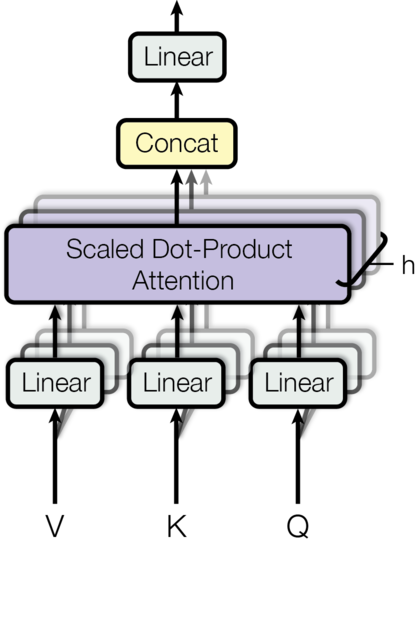

<div>

This translates to the following mathematical formula:

$$
\mathrm{MultiHead}(Q, K, V) =
    \mathrm{Concat}(\mathrm{head_1}, ..., \mathrm{head_h})W^O \\
    \text{where}~\mathrm{head_i} = \mathrm{Attention}(QW^Q_i, KW^K_i, VW^V_i)
$$

Where the projections are parameter matrices $W^Q_i \in
\mathbb{R}^{d_{\text{model}} \times d_k}$, $W^K_i \in
\mathbb{R}^{d_{\text{model}} \times d_k}$, $W^V_i \in
\mathbb{R}^{d_{\text{model}} \times d_v}$ and $W^O \in
\mathbb{R}^{hd_v \times d_{\text{model}}}$.

Let's briefly discuss **Dropout**, a technique you'll see often when building models like GPT.

Dropout is a smart way to **prevent a neural network from overfitting** by encouraging more robust learning. During training, it randomly "turns off" a fraction of neurons in a layer. This forces the remaining active neurons to learn independently and contribute more meaningfully, as they can't rely on specific teammates. Essentially, it's like training a diverse ensemble of slightly different networks simultaneously.

The core benefit is **regularization**: it stops the model from simply memorizing the training data, ensuring it generalizes better to new, unseen information. Importantly, Dropout is only active during training; all neurons are used during prediction.

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, n_embd, head_size, block_size, dropout=0.1):
        super().__init__()
        # Step 1: Create a ModuleList of AttentionHead instances.
        # Each AttentionHead will operate in parallel, focusing on different aspects of the input.
        self.heads = nn.ModuleList([AttentionHead(n_embd, head_size, block_size, dropout=dropout) for _ in range(num_heads)])
        # Step 2: Initialize a Linear layer for projection.
        # This layer will combine the outputs from all attention heads back into the original embedding dimension.
        self.proj = nn.Linear(n_embd, n_embd)

        # Here we initialize a Dropout layer for regularization after the projection.
        self.dropout = nn.Dropout(dropout)

    def _apply_individual_attention_heads(self, x):
      # Step 3: This method applies each of the initialized attention heads to the input `x`.
      # Each head will produce its own output based on its internal computations.
      # Gather the results and return them as a list
      return [h(x) for h in self.heads]

    def _concatenate_head_outputs(self, outputs):
      # Step 4: This method concatenates the outputs from all individual attention heads.
      # The concatenation occurs along the last dimension to combine their results.
      return torch.cat(outputs, dim=-1)

    def _project_output(self, outputs):
      # Step 5: Apply the projection layer to the concatenated output.
      # This linearly transforms the combined output from all heads.
      return self.proj(outputs)

    def forward(self, x):
        out = self._apply_individual_attention_heads(x)
        out = self._concatenate_head_outputs(out)
        out = self._project_output(out)

        # Finally, we apply dropout to the projected output for regularization.
        out = self.dropout(out)
        return out

> Instead of creating separate modules for each attention head and concatenating their outputs, a more optimized approach involves performing a single, larger linear projection for all queries, keys, and values. The resulting tensor is then simply **reshaped (or "viewed") to implicitly create and handle the multiple heads in parallel**, before the final concatenation and projection. This avoids the overhead of managing `nn.ModuleList` and explicit concatenation calls, streamlining the computation.

**Do not modify these cells as it used to verify that your implementation is correct and avoid future bugs.**

In [ ]:
# @title Testing the `MultiHeadAttention` module

!wget -q 'https://huggingface.co/datasets/VaMaSi/athnlp-lab3/resolve/main/multi_head_attention_concatenated.pt?download=true' -O multi_head_attention_concatenated.pt
!wget -q 'https://huggingface.co/datasets/VaMaSi/athnlp-lab3/resolve/main/multi_head_attention_expected_output.pt?download=true' -O multi_head_attention_expected_output.pt

def test_multi_head_attention_components() -> None:
    """Test the MultiHeadAttention module's individual components and overall functionality.
    Provides detailed feedback for each step and raises an AssertionError on failure.
    """
    # Define common parameters
    batch_size = 16
    block_size = 16
    n_embd = 128
    num_heads = 4
    head_size = n_embd // num_heads  # Typical way to determine head_size

    # Initialize the MultiHeadAttention module for testing
    torch.manual_seed(42)  # for reproducibility
    multi_head = MultiHeadAttention(
        num_heads, n_embd, head_size, block_size, dropout=0.0  # Set dropout to 0 for deterministic testing
    )

    # Create dummy input data (same as used for generating expected outputs)
    x = torch.randn(batch_size, block_size, n_embd)
    B, T, C = x.shape

    print("--- Starting MultiHeadAttention Component Tests ---")

    # --- Test 1: _apply_individual_attention_heads ---
    print("\nTesting _apply_individual_attention_heads...")
    head_outputs_student = multi_head._apply_individual_attention_heads(x)

    # Each head's output should have shape (B, T, head_size)
    expected_head_output_shape = (batch_size, block_size, head_size)
    assert len(head_outputs_student) == num_heads, \
        f"FAILED: _apply_individual_attention_heads - Expected {num_heads} outputs, got {len(head_outputs_student)}.\n" \
        "Hint: Ensure all attention heads in the ModuleList are applied."
    print("PASSED: _apply_individual_attention_heads - Correct number of head outputs.")

    for i, output in enumerate(head_outputs_student):
        assert output.shape == expected_head_output_shape, \
            f"FAILED: _apply_individual_attention_heads - Head {i} output shape mismatch! Expected {expected_head_output_shape}, got {output.shape}.\n" \
            "Hint: Each attention head should produce an output of shape (Batch, SequenceLength, HeadSize)."
    print("PASSED: _apply_individual_attention_heads - All individual head output shapes match expected.")

    # We can't directly compare all individual head outputs without saving them all,
    # but the concatenation test will implicitly verify their correctness.

    # --- Test 2: _concatenate_head_outputs ---
    print("\nTesting _concatenate_head_outputs...")
    # Use the outputs from the previous successful step (or re-generate if needed)
    concatenated_output_student = multi_head._concatenate_head_outputs(head_outputs_student)
    concatenated_output_expected = torch.load("multi_head_attention_concatenated.pt")

    # Assert shape first
    expected_concatenated_shape = (batch_size, block_size, n_embd) # B, T, num_heads * head_size which is n_embd
    assert concatenated_output_student.shape == expected_concatenated_shape, \
        f"FAILED: _concatenate_head_outputs - Concatenated output shape mismatch! Expected {expected_concatenated_shape}, got {concatenated_output_student.shape}.\n" \
        "Hint: Concatenation should happen along the last dimension (dim=-1) to combine head_size * num_heads into n_embd."
    print("PASSED: _concatenate_head_outputs - Concatenated output shape matches expected.")

    # Then assert values
    assert torch.allclose(concatenated_output_student, concatenated_output_expected, atol=1e-6), \
        "FAILED: _concatenate_head_outputs - Concatenated output value mismatch!\n" \
        "Hint: Verify that `torch.cat` is used correctly with `dim=-1` on the list of head outputs."
    print("PASSED: _concatenate_head_outputs - Concatenated output values match expected.")


    # --- Test 3: _project_output ---
    print("\nTesting _project_output...")
    # Use the expected concatenated output for this test to isolate the function
    concatenated_output_loaded = torch.load("multi_head_attention_concatenated.pt")

    projected_output_student = multi_head._project_output(concatenated_output_loaded)
    projected_output_expected = torch.load("multi_head_attention_expected_output.pt")

    # Assert shape first
    expected_projected_shape = (batch_size, block_size, n_embd)
    assert projected_output_student.shape == expected_projected_shape, \
        f"FAILED: _project_output - Projected output shape mismatch! Expected {expected_projected_shape}, got {projected_output_student.shape}.\n" \
        "Hint: The projection layer should map the concatenated output back to the original embedding dimension (n_embd)."
    print("PASSED: _project_output - Projected output shape matches expected.")

    # Then assert values
    assert torch.allclose(projected_output_student, projected_output_expected, atol=1e-6), \
        "FAILED: _project_output - Projected output value mismatch!\n" \
        "Hint: Check the `self.proj` linear layer application. The bias should be included by default in nn.Linear."
    print("PASSED: _project_output - Projected output values match expected.")

    print("\n--- Starting Full MultiHeadAttention Module Tests ---")

    # --- Full Module Test 1: Output Shape ---
    print("\nTesting full MultiHeadAttention module (Output Shape)...")
    torch.manual_seed(42)
    x_full_test = torch.randn(batch_size, block_size, n_embd)
    output_student_full = multi_head(x_full_test)

    expected_output_shape = (batch_size, block_size, n_embd)
    assert output_student_full.shape == expected_output_shape, \
        f"FAILED: Full Module Output Shape - Expected {expected_output_shape}, got {output_student_full.shape}\n" \
        "Hint: The final output shape should be (Batch, SequenceLength, EmbeddingDimension)."
    print("PASSED: Full Module Output Shape - Correct shape.")

    # --- Full Module Test 2: Deterministic Output with Fixed Seed ---
    print("\nTesting full MultiHeadAttention module (Deterministic Output)...")
    torch.manual_seed(42)
    multi_head2 = MultiHeadAttention(num_heads, n_embd, head_size, block_size, dropout=0.0)
    x2 = torch.randn(batch_size, block_size, n_embd)
    output2 = multi_head2(x2)

    # Re-run the first instance with the same seed to compare
    torch.manual_seed(42)
    multi_head_initial = MultiHeadAttention(num_heads, n_embd, head_size, block_size, dropout=0.0)
    x_initial = torch.randn(batch_size, block_size, n_embd)
    output_initial = multi_head_initial(x_initial)

    assert torch.allclose(output_initial, output2, atol=1e-6), \
        "FAILED: Full Module Deterministic Output - Running the module twice with the same seed and input yields different results.\n" \
        "Hint: Ensure all operations are deterministic and no random elements are present when dropout is 0. This might involve checking the AttentionHead modules as well."
    print("PASSED: Full Module Deterministic Output - Consistent results with fixed seed.")

    # --- Full Module Test 3: Compare against Expected Final Output ---
    print("\nTesting full MultiHeadAttention module (Against Pre-computed Expected Output)...")
    torch.manual_seed(42) # Ensure student's forward pass starts from the same state
    multi_head_final_test = MultiHeadAttention(num_heads, n_embd, head_size, block_size, dropout=0.0)
    x_final_test = torch.randn(batch_size, block_size, n_embd)
    output_student_final = multi_head_final_test(x_final_test)

    expected_final_output = torch.load("multi_head_attention_expected_output.pt")

    # Assert shape first
    expected_final_output_shape = (batch_size, block_size, n_embd)
    assert output_student_final.shape == expected_final_output_shape, \
        f"FAILED: Full Module Expected Output - Final output shape mismatch! Expected {expected_final_output_shape}, got {output_student_final.shape}.\n" \
        "Hint: The final output of MultiHeadAttention should be (Batch, SequenceLength, EmbeddingDimension)."
    print("PASSED: Full Module Expected Output - Final output shape matches expected.")

    # Then assert values
    is_output_close = torch.allclose(output_student_final, expected_final_output, atol=1e-6)
    assert is_output_close, \
        "FAILED: Full Module Expected Output - Your final MultiHeadAttention output values do NOT match the pre-computed expected output.\n" \
        "Hint: This usually means one of your internal calculations (_apply_individual_attention_heads, _concatenate_head_outputs, _project_output) or the overall flow in `forward` is incorrect."
    print("PASSED: Full Module Expected Output - Your full module output (shape and values) matches the pre-computed expected output. Excellent work!")

    print("\n--- All MultiHeadAttention tests completed successfully! ---")

# Run the tests
test_multi_head_attention_components()

## 🧭 Positional Embeddings

In the original Transformer model, the embeddings of a token $m$, $x_m$ are summed with a positional encoding function $PE(m)$, so that:

$$\mathbf{x_m}' = \mathbf{x_m} + PE(m)$$

**Question** Why do you think we need positional information in Transformers?

<details>
<summary><strong>Answer</strong></summary>

> The attention operation itself is **permutation invariant**: it does not know the order in which tokens appear. If we take a sequence and randomly shuffle its tokens, the attention mechanism will compute the same relationships between tokens, just in a different arrangement.
>
> However, word order is essential for understanding language. For example, the sentences *"Transformers are better than RNNs"* and *"RNNs are better than Transformers"* contain exactly the same tokens, but their meanings are opposite.
>
> To address this, we provide each token with additional **positional information** before applying attention. This allows the Transformer to distinguish not only *which* tokens are present, but also *where* each token appears in the sequence. A simple addition of positional encodings to the input embeddings is enough to give the model access to this ordering information.

</details>

The original Transformer model applies sine and cosine functions of different frequencies to model positional information:

$$PE_{(pos,2i)} = \sin(pos / 10000^{2i/d_{\text{model}}})$$

$$PE_{(pos,2i+1)} = \cos(pos / 10000^{2i/d_{\text{model}}})$$

In the example below, we show the impact of the sinusoidal positional embeddings applied to a sequence of embeddings. For simplicity, assume that the embeddings have two dimensions and each token in the sequence is a vector $x = [1, 1]$.

Notice that both the magnitude and the angle of the same embedding vector ($x = [1, 1]$) are impacted significantly. As we will see later on, this is not a good practice and sinusoidal embeddings are one of the few things that has changed over the original Transformer. The reason for this is that the model perceives a token by its embedding. From this graph, the same token can have very different embeddings, after positional encoding making it challenging for the model to understand that all of these vectors refer to the same token.

In [ ]:
def example_positional_2d() -> alt.Chart:
    """Example of positional information on a 2D vector."""
    d_model = 2
    max_len = 8
    base = 10000.0
    input_vector = torch.ones(max_len, d_model)

    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(base) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    embedding = input_vector + pe

    data = pd.concat(
        [
            pd.DataFrame(
                {
                    "x": [0, embedding[n, 0].item()],
                    "y": [0, embedding[n, 1].item()],
                    "position": n,
                }
            )
            for n in list(range(max_len))
        ]
    )

    return (
        alt.Chart(data)
        .mark_line()
        .properties(width=800)
        .encode(x="x", y="y", color="position:N")
        .interactive()
    )

example_positional_2d()

**We will focus on a simple yet effective alternative.**

**Learnable Positional Embeddings**: Create a learnable positional embedding layer matching your token embedding size, initialized randomly. For each sequence, generate position indices (0, 1, 2, ...), pass them through this layer to get positional embeddings, and add these element-wise to your token embeddings.

## 🤔 What else are we missing?

Looking at the original Transformer architecture, the decoder (on the right) is structured into blocks that include:

1. **Feed Forward Neural Network**: introduce non-linearity and refine token representations independently at each position, complementing the global understanding provided by self-attention.
2. **Layer Normalization**: stabilizes training and accelerates convergence by normalizing the activations across the features for each sample independently, preventing issues like vanishing/exploding gradients in deep Transformer networks.
3. **Residual/Skip Connections**: facilitate training of deep networks by providing a direct path for gradients, which mitigates vanishing/exploding gradients, preserves information flow, and eases optimization.

<div align="center">

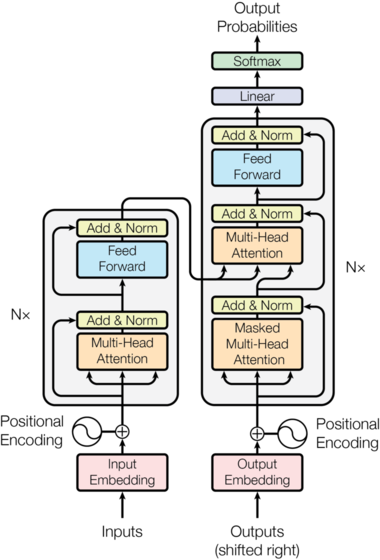

Layer Normalization ensures training stability and faster convergence by standardizing the activations within each individual sample across its feature dimensions. It essentially gives each sample's features a consistent mean (0) and variance (1), preventing issues like vanishing or exploding gradients in deep networks, regardless of batch size.

Layer Normalization trains by learning a scaling factor (gamma) and a shifting factor (beta) for each feature dimension. These parameters are updated via backpropagation along with the rest of the model, allowing the network to "undo" or adapt the normalization if it helps the learning process.

In [ ]:
class LayerNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

  def __call__(self, x):
    xmean = x.mean(1, keepdim=True) # batch mean
    xvar = x.var(1, keepdim=True) # batch variance
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

In [ ]:
torch.manual_seed(1337)
module = LayerNorm1d(100)
x = torch.randn(32, 100)
x = module(x)
print(x.shape)
print(x[0,:].mean(), x[0,:].std()) # mean,std of a single input from the batch, of its features

Let's look at the "Feed-Forward Network" (FFN), another key building block in the Transformer.

Think of the FFN as a small, independent neural network that processes each token's information *after* it has passed through the attention mechanism. It's like giving each token a chance to "think further" about its context.

Specifically, it works by:
1.  **Expanding:** Taking the token's initial representation and expanding it into a higher-dimensional space (e.g., 4 times larger). This gives it more room to learn complex patterns.
2.  **Activating:** Applying a non-linear activation (like ReLU) to introduce non-linearity, allowing the network to model more intricate relationships.
3.  **Contracting:** Finally, it projects this expanded, refined information back down to the original size of the token's representation.

This process, applied identically to every token's position, provides crucial non-linearity and further enhances the model's ability to learn rich features from the data.

In [ ]:
class FeedFoward(nn.Module):
    """a simple linear layer followed by a non-linearity"""

    def __init__(self, n_embd, dropout=0.1):
        super().__init__()
        # In the original implementation
        self.net = nn.Sequential(
            # In the original paper, position-wise feedforward networks had an input and output dimension of 512,
            # with an inner-layer dimensionality of 2048, representing a multiplier of 4.
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

Now, let's put it all together into a complete **Transformer Block**. Each block takes in a token's representation and refines it through two main phases:

1.  **Communication (Multi-Head Attention):** First, the block allows each token to "talk" to all other tokens in the sequence. It uses **Multi-Head Attention** to understand relationships and gather context from across the entire input. This is where the model figures out which parts of the input are most relevant to each token.
2.  **Computation (Feed-Forward Network):** After the communication phase, the block then performs an independent "computation" on each token's refined representation using a **Feed-Forward Network**. This is where the model adds non-linearity and further processes the newly contextualized information for each individual token.

Crucially, throughout these steps, **Layer Normalization** is applied to stabilize the process and ensure smooth training, and **skip connections** (residual connections) are used to allow information to flow easily through the deep layers and help gradients propagate effectively.

By stacking many of these "blocks," the Transformer can build up a sophisticated understanding of sequences, layer by layer.

In [ ]:
class Block(nn.Module):
    """Transformer block: communication followed by computation"""

    def __init__(self, n_embed, n_head, block_size=128, dropout=0.1):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embed // n_head
        self.mha = MultiHeadAttention(n_head, n_embed, head_size, block_size, dropout=dropout)
        self.ffwd = FeedFoward(n_embed)
        self.ln1 = nn.LayerNorm(n_embed)
        self.ln2 = nn.LayerNorm(n_embed)

    def forward(self, x):
        x = x + self.mha(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

## 📜 To be or not to be...

With these fundamental building blocks understood, we're now ready to construct the final language model!

- We employ 4 attention heads with a head size of 16 (64/4).
- We truncate to `block_size` during `generate` because the model's attention and positional encodings only handle `block_size` tokens, matching training conditions and ensuring correct attention behavior during generation.

In [ ]:
class LanguageModel(nn.Module):
    def __init__(self, vocab_size, n_head=4, n_layer=4, block_size=128, n_embed=64, dropout=0.1):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embed)
        self.position_embedding_table = nn.Embedding(block_size, n_embed)
        self.blocks = nn.Sequential(*[Block(n_embed, n_head=n_head, block_size=block_size, dropout=dropout) for _ in range(n_layer)])
        self.norm = nn.LayerNorm(n_embed) # final layer norm
        self.head = nn.Linear(n_embed, vocab_size)

    def predict_logits(self, input_ids):
        """Predict logits for each token in the sequence.

        Same interface as Lab 2's LanguageModel.predict_logits.
        """
        B, T = input_ids.shape
        token_embeddings = self.token_embedding_table(input_ids) # (B,T,C)
        position_embeddings = self.position_embedding_table(
            torch.arange(T, device=input_ids.device)
        ) # (T,C)
        embeddings = token_embeddings + position_embeddings
        embeddings = self.blocks(embeddings) # (B,T,C)
        embeddings = self.norm(embeddings) # (B,T,C)
        logits = self.head(embeddings) # (B,T,vocab_size)
        return logits

    def compute_loss(self, logits, input_ids):
        """Compute cross-entropy loss from logits and input_ids (same as Lab 2).

        Shifts logits and input_ids internally for autoregressive loss: logits
        at position t predict input_ids at position t+1.
        """
        logits = logits[:, :-1]       # (B, T-1, vocab_size)
        input_ids = input_ids[:, 1:]  # (B, T-1)
        B, T, C = logits.shape
        loss = F.cross_entropy(
            logits.reshape(B * T, C),
            input_ids.reshape(B * T),
        )
        return loss

    def forward(self, input_ids: torch.Tensor, **kwargs: Any) -> dict[str, torch.Tensor]:
        logits = self.predict_logits(input_ids)
        loss = self.compute_loss(logits, input_ids)
        return {"logits": logits, "loss": loss}

In [ ]:
model = LanguageModel(vocab_size=tokenizer.vocab_size)

In [ ]:
# @title Training with HF Trainer (same as Lab 2)
training_args = TrainingArguments(
    learning_rate=0.01,
    per_device_train_batch_size=5,
    num_train_epochs=5,            # Limited to 5 epochs for faster execution
    weight_decay=0.1,
    max_grad_norm=1.0,
    output_dir="lab3",
    logging_steps=100,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset,
    eval_dataset=tokenized_dataset,
    processing_class=tokenizer,
)

trainer.train()

In [ ]:
# @title Autoregressive generation (same as Lab 2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

@torch.inference_mode()
def generate(model, tokenizer, prompt, max_new_tokens=100, block_size=128, seed=1337):
    """Generate text continuation from a prompt using multinomial sampling."""
    torch.manual_seed(seed)
    model.eval()
    input_ids = tokenizer.encode(prompt, add_special_tokens=False)
    context = torch.tensor(input_ids, dtype=torch.long, device=device).unsqueeze(0).to()
    for _ in range(max_new_tokens):
        context_trunc = context[:, -block_size:]
        logits = model.predict_logits(context_trunc)
        logits_last = logits[:, -1, :]
        probs = torch.softmax(logits_last, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        context = torch.cat((context, next_id), dim=1)
    model.train()
    return tokenizer.decode(context[0].tolist())

In [ ]:
prompt = "From fairest creatures we"
output = generate(trainer.model, tokenizer, prompt, max_new_tokens=200)
print(f"Prompt: {prompt}")
print(f"Generated: {output}")

## ⛳ Some Final Remarks

Training a Large Language Model (LLM) is a two-main-step journey:

1.  **Pre-training (Learning the Basics):**
  In this first, crucial step, the LLM reads a vast amount of text and code. Its primary job is simple: predict the very next word in a sentence. By doing this countless times, it learns grammar, how words connect, and even some world knowledge. This phase is self-supervised, meaning the "answers" are already in the text itself.

  For our example, instead of a massive internet-scale dataset, we trained our LLM on a much smaller, more manageable dataset: "Tiny Shakespeare." This allows us to observe the pre-training process and understand its mechanics without needing immense computational resources. Our model learned to predict the next token based purely on Shakespeare's writing style, vocabulary, and patterns.

2.  **Reinforcement Learning from Human Feedback (RLHF - Learning to Be Helpful):**
    * **Human Examples:** First, humans show the model good ways to respond to prompts.
    * **AI Judge:** Then, a separate AI is trained to act like a "judge," learning to rate how good, helpful, or safe the LLM's answers are, based on many human rankings.
    * **Practice & Improve:** Finally, the LLM practices responding, and the "AI judge" gives it scores. The LLM then learns to adjust its answers to get higher scores, becoming much better at understanding and fulfilling what people actually want.



<div align="center">
  <img src="https://images.ctfassets.net/kftzwdyauwt9/6yuK9FKAvoVXNyrsdMoBHH/03ccaf7da203052ba7550965f0021bdf/chatgpt_diagram_dark.png?w=1920&q=80&fm=webp"/>
  <a href="https://openai.com/index/chatgpt/">
    <figcaption align = "center"> From "Introducing ChatGPT" November 30, 2022 </figcaption>
  </>
</div>

> 🎉 **Congratulations on building your own GPT from scratch!**
>
> Just like our models need RLHF to become helpful, we rely on your feedback to improve future sessions. Knowing which parts of the Transformer clicked and what felt like a bottleneck helps us adjust the pacing for everyone.
>
> 📝 **[Take the 3-Minute Feedback Survey](https://docs.google.com/forms/d/e/1FAIpQLSfIta0qlhdDM_e-jJbqoEJiGu9BygWUQ_P7Ya7VPICkojAzyQ/viewform?usp=dialog)**